In [4]:
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
# Load both CSVs
metrics_xgb = pd.read_csv("xgboost_metrics.csv", index_col=0)
metrics_rf = pd.read_csv("random_forest_metrics.csv", index_col=0)

# Preview
print(metrics_xgb)
print(metrics_rf)

                          accuracy  precision    recall        f1       auc
Baseline (No Resampling)  0.948362   1.000000  0.743094  0.852615  0.990161
1:1 Undersample           0.951694   0.806236  1.000000  0.892725  0.991087
1.5:1 Undersample         0.950028   0.806306  0.988950  0.888337  0.990640
2:1 Undersample           0.941144   0.921053  0.773481  0.840841  0.990295
SMOTE Oversample          0.951694   0.806236  1.000000  0.892725  0.991228
                          accuracy  precision    recall        f1       auc
Baseline (No Resampling)  0.923931   0.854890  0.748619  0.798233  0.975868
1:1 Undersample           0.951694   0.806236  1.000000  0.892725  0.992010
1.5:1 Undersample         0.951694   0.806236  1.000000  0.892725  0.991722
2:1 Undersample           0.948362   1.000000  0.743094  0.852615  0.991824
SMOTE Oversample          0.924486   0.726908  1.000000  0.841860  0.991318


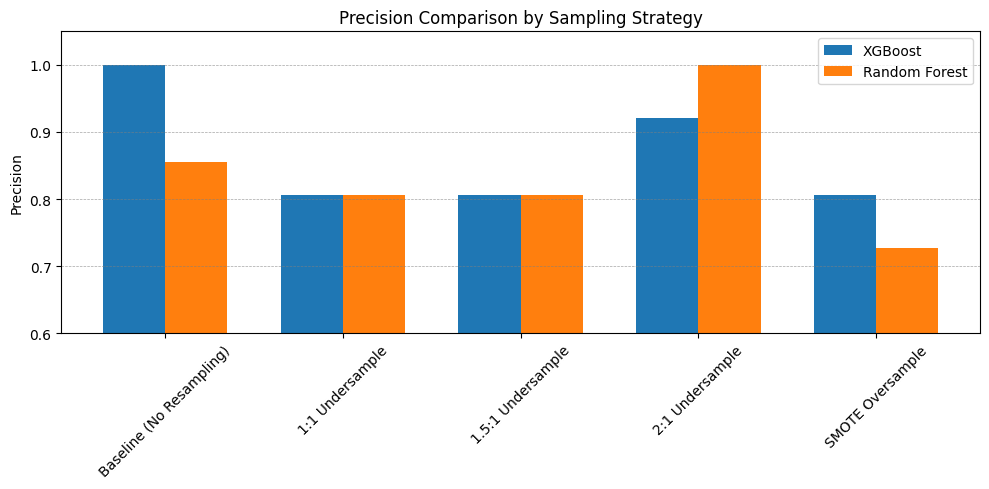

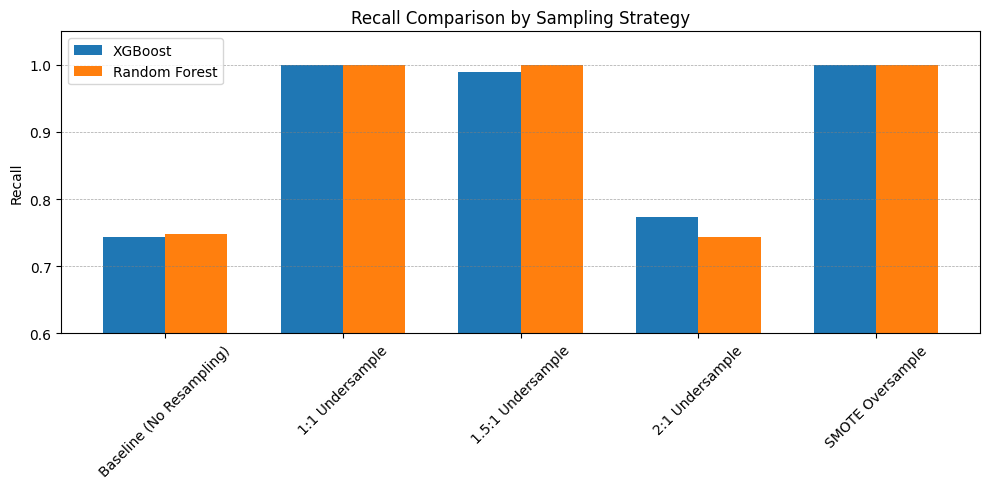

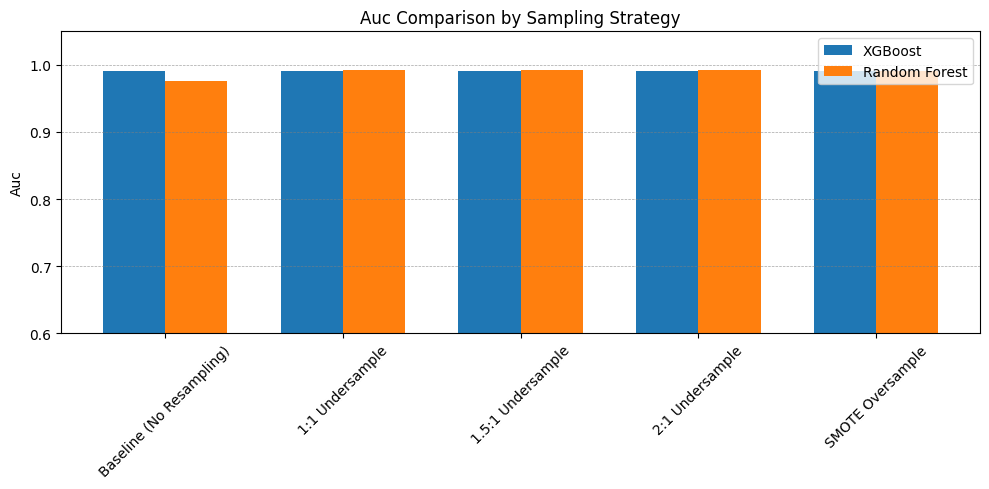

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSVs (if not already loaded)
metrics_xgb = pd.read_csv("xgboost_metrics.csv", index_col=0)
metrics_rf = pd.read_csv("random_forest_metrics.csv", index_col=0)

# Sampling strategies from index
sampling_strategies = metrics_xgb.index.tolist()
metrics_to_plot = ["precision", "recall", "auc"]  # Focus on key metrics

# Plot side-by-side bar charts
for metric in metrics_to_plot:
    plt.figure(figsize=(10, 5))
    x = range(len(sampling_strategies))
    bar_width = 0.35

    plt.bar(
        [i - bar_width / 2 for i in x],
        metrics_xgb[metric],
        width=bar_width,
        label="XGBoost",
    )
    plt.bar(
        [i + bar_width / 2 for i in x],
        metrics_rf[metric],
        width=bar_width,
        label="Random Forest",
    )

    plt.xticks(ticks=x, labels=sampling_strategies, rotation=45)
    plt.ylim(0.6, 1.05)
    plt.ylabel(metric.capitalize())
    plt.title(f"{metric.capitalize()} Comparison by Sampling Strategy")
    plt.legend()

    # 🔥 Add mini, light gridlines
    plt.grid(axis="y", color="gray", linestyle="--", linewidth=0.5, alpha=0.7)

    plt.tight_layout()
    plt.show()